# Automated Regional Impact Auditor (ARIA) v2.0 - 花蓮縣專版
## 花蓮縣地形整合河川洪災避難所風險評估

### Captain's Log: Mission Brief
本分析任務專注於評估**花蓮縣**境內避難所的洪災風險，利用水利署河川圖資建立三級警戒緩衝區，結合內政部 20m DEM 地形資料與消防署避難收容所資料，識別高風險區域並評估收容量缺口。

**ARIA v2.0 花蓮縣專版特色：**
- 限定花蓮縣範圍的精準分析
- 整合 20m DEM 地形分析（坡度、高程）
- 複合風險評估（河川距離 + 地形因子）
- 進階視覺化（DEM Hillshade 地圖）

**分析流程：**
1. 花蓮縣資料載入與清理
2. DEM 地形處理與分析
3. 三級緩衝區建立
4. 複合風險分級評估
5. 地形統計與 Zonal Analysis
6. 視覺化與結果匯出

**資料來源：** 本地 `/data/` 目錄
**分析範圍：** 花蓮縣行政區域

In [1]:
# 基礎套件載入
import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
import json
from dotenv import load_dotenv
import os
from urllib.parse import quote
import warnings
warnings.filterwarnings('ignore')

# Week 4 新增地形分析套件
import rioxarray
import numpy as np
from rasterstats import zonal_stats
from shapely.geometry import box

# 載入環境變數
load_dotenv()

# Week 4 地形分析環境變數 (從 .env 讀取)
SLOPE_THRESHOLD = int(os.getenv('SLOPE_THRESHOLD_DEGREES', 30))
ELEVATION_THRESHOLD = int(os.getenv('ELEVATION_THRESHOLD_METERS', 50))
BUFFER_DISTANCE = int(os.getenv('BUFFER_DISTANCE_METERS', 500))
DEM_CLIP_BUFFER = int(os.getenv('DEM_CLIP_BUFFER', 1000))

# 風險分級門檻
EXTREME_RISK_SLOPE = int(os.getenv('EXTREME_RISK_SLOPE', 60))
HIGH_RISK_SLOPE = int(os.getenv('HIGH_RISK_SLOPE', 45))
MEDIUM_RISK_SLOPE = int(os.getenv('MEDIUM_RISK_SLOPE', 30))
LOW_RISK_ELEVATION = int(os.getenv('LOW_RISK_ELEVATION', 100))

# 輸出設定
OUTPUT_CRS = os.getenv('OUTPUT_CRS', 'EPSG:3826')
DEBUG_MODE = os.getenv('DEBUG_MODE', 'True').lower() == 'true'

# 原有河川緩衝區設定 (保持向後兼容)
BUFFER_HIGH = BUFFER_DISTANCE
BUFFER_MED = BUFFER_DISTANCE * 2
BUFFER_LOW = BUFFER_DISTANCE * 4

# 目標縣市設定
TARGET_COUNTY = os.getenv('TARGET_COUNTY', '花蓮縣')

print(f"=== ARIA v2.0 環境配置 ===")
print(f"地形分析設定:")
print(f"  坡度門檻: {SLOPE_THRESHOLD}°")
print(f"  高程門檻: {ELEVATION_THRESHOLD}m")
print(f"  緩衝區距離: {BUFFER_DISTANCE}m")
print(f"  DEM 裁切緩衝: {DEM_CLIP_BUFFER}m")
print(f"風險分級門檻:")
print(f"  極高風險坡度: {EXTREME_RISK_SLOPE}°")
print(f"  高風險坡度: {HIGH_RISK_SLOPE}°")
print(f"  中風險坡度: {MEDIUM_RISK_SLOPE}°")
print(f"  低風險高程: {LOW_RISK_ELEVATION}m")
print(f"河川緩衝區設定:")
print(f"  高風險: {BUFFER_HIGH}m, 中風險: {BUFFER_MED}m, 低風險: {BUFFER_LOW}m")
print(f"目標縣市: {TARGET_COUNTY}")
print(f"輸出 CRS: {OUTPUT_CRS}")
print(f"除錯模式: {DEBUG_MODE}")

=== ARIA v2.0 環境配置 ===
地形分析設定:
  坡度門檻: 30°
  高程門檻: 50m
  緩衝區距離: 500m
  DEM 裁切緩衝: 1000m
風險分級門檻:
  極高風險坡度: 60°
  高風險坡度: 45°
  中風險坡度: 30°
  低風險高程: 100m
河川緩衝區設定:
  高風險: 500m, 中風險: 1000m, 低風險: 2000m
目標縣市: 花蓮縣
輸出 CRS: EPSG:3826
除錯模式: True


## 1. 本地資料載入與清理

### Captain's Log: Local Data Acquisition Phase
從本地 `/data/` 目錄載入三個核心資料集：水利署河川面、消防署避難所、國土測繪中心鄉鎮界。重點關注 CRS 轉換與資料清理。

**資料路徑配置：**
- 河川資料：`/data/riverpoly/riverpoly.shp`
- 避難所：`/data/避難收容處所點位檔案v9.csv`
- 鄉鎮界：`/data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp`
- DEM：`/data/dem_20m_hualien.tif`

In [2]:
# 1.1 載入水利署河川面資料並篩選花蓮縣附近河川
print("載入水利署河川面資料...")

# 從本地 /data 目錄載入河川資料
rivers_path = r'data/riverpoly/riverpoly.shp'
try:
    rivers = gpd.read_file(rivers_path)
    print(f"河川資料載入成功: {rivers_path}")
except FileNotFoundError:
    print(f"找不到河川資料檔案: {rivers_path}")
    print("請確認檔案是否位於 /data/riverpoly/ 目錄中")
    raise

print(f"原始河川資料: {len(rivers)} 筆記錄")
print(f"原始 CRS: {rivers.crs}")
print(f"資料欄位: {list(rivers.columns)}")
print(f"範圍: {rivers.total_bounds}")

# 確保在 EPSG:3826 (TWD97)
if rivers.crs != 'EPSG:3826':
    rivers = rivers.to_crs('EPSG:3826')
    print(f"轉換至 EPSG:3826: {rivers.crs}")

# 篩選花蓮縣附近的河川
print(f"\n篩選花蓮縣附近河川...")

# 花蓮縣大致範圍 (TWD97)
hualien_bounds = box(250000, 2600000, 310000, 2680000)
hualien_buffer = box(245000, 2595000, 315000, 2685000)  # 加上5km緩衝

# 篩選與花蓮縣相交的河川
rivers_hualien = rivers[rivers.geometry.intersects(hualien_buffer)].copy()

print(f"花蓮縣附近河川: {len(rivers_hualien)} 筆記錄")
print(f"篩選後範圍: {rivers_hualien.total_bounds}")

if len(rivers_hualien) > 0:
    print(f"河川名稱樣本: {rivers_hualien['RIVER_NAME'].unique()[:10]}")
    rivers = rivers_hualien
else:
    print("⚠️ 未找到花蓮縣附近河川，使用全部河川資料")

載入水利署河川面資料...
河川資料載入成功: data/riverpoly/riverpoly.shp
原始河川資料: 13262 筆記錄
原始 CRS: EPSG:3826
資料欄位: ['RIVER_NAME', 'RIVER_TYPE', 'RIVER_CODE', 'RIVER_FROM', 'geometry']
範圍: [ 153837.36653789 2422957.34119449  351449.97985007 2798615.14187825]

篩選花蓮縣附近河川...
花蓮縣附近河川: 568 筆記錄
篩選後範圍: [ 231782.04340861 2574337.25074856  315803.44304726 2688778.19311508]
河川名稱樣本: <StringArray>
['志樂溪', '合歡溪', '大甲溪', '裡冷溪', '碧綠溪', '黃肉溪', '塔羅灣溪', '萬大溪', '鹽土溪', '郡大溪']
Length: 10, dtype: str


In [3]:
# 1.2 載入消防署避難所資料
print("\n載入消防署避難所資料...")

# 從本地 /data 目錄載入避難所資料
shelters_path = r'data/避難收容處所點位檔案v9.csv'
try:
    shelters_csv = pd.read_csv(shelters_path, encoding='utf-8')
    print(f"避難所資料載入成功: {shelters_path}")
except FileNotFoundError:
    print(f"找不到避難所資料檔案: {shelters_path}")
    print("請確認檔案是否位於 /data/ 目錄中")
    raise

print(f"避難所 CSV 載入完成: {len(shelters_csv)} 筆記錄")
print(f"欄位: {list(shelters_csv.columns)}")

# 檢查座標欄位名稱
lon_cols = [col for col in shelters_csv.columns if '經' in col or 'lon' in col.lower()]
lat_cols = [col for col in shelters_csv.columns if '緯' in col or 'lat' in col.lower()]
capacity_cols = [col for col in shelters_csv.columns if '收容' in col or 'capacity' in col.lower()]

print(f"經度欄位: {lon_cols}")
print(f"緯度欄位: {lat_cols}")
print(f"收容人數欄位: {capacity_cols}")


載入消防署避難所資料...
避難所資料載入成功: data/避難收容處所點位檔案v9.csv
避難所 CSV 載入完成: 5973 筆記錄
欄位: ['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', '避難收容處所名稱', '預計收容村里', '預計收容人數', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置']
經度欄位: ['經度']
緯度欄位: ['緯度']
收容人數欄位: ['避難收容處所地址', '避難收容處所名稱', '預計收容村里', '預計收容人數']


In [4]:
# 1.3 資料清理 - 移除無效座標並篩選花蓮縣避難所
print("\n開始資料清理...")

# 假設欄位名稱（根據實際資料調整）
lon_col = lon_cols[0] if lon_cols else '經度'
lat_col = lat_cols[0] if lat_cols else '緯度'
# 修復：使用正確的收容人數欄位
capacity_col = '預計收容人數'  # 根據實際資料欄位
name_col = '避難收容處所名稱'  # 使用正確的名稱欄位
county_col = '縣市及鄉鎮市區'  # 縣市欄位

# 記錄清理前筆數
original_count = len(shelters_csv)
print(f"清理前: {original_count} 筆記錄")

# 移除座標為 0 或空值的記錄
shelters_clean = shelters_csv[
    (shelters_csv[lon_col].notna()) &
    (shelters_csv[lat_col].notna()) &
    (shelters_csv[lon_col] != 0) &
    (shelters_csv[lat_col] != 0)
].copy()

# 移除超出台灣範圍的座標
shelters_clean = shelters_clean[
    (shelters_clean[lon_col] >= 119) & (shelters_clean[lon_col] <= 122) &
    (shelters_clean[lat_col] >= 21) & (shelters_clean[lat_col] <= 26)
]

# 篩選花蓮縣避難所
print(f"\n篩選花蓮縣避難所...")
hualien_shelters = shelters_clean[
    shelters_clean[county_col].str.contains('花蓮', na=False)
].copy()

print(f"花蓮縣避難所: {len(hualien_shelters)} 筆記錄")
if len(hualien_shelters) > 0:
    print(f"花蓮縣行政區: {hualien_shelters[county_col].unique()}")
else:
    print("⚠️ 未找到花蓮縣避難所，使用全部資料繼續分析")
    hualien_shelters = shelters_clean.copy()

cleaned_count = len(hualien_shelters)
print(f"最終篩選結果: {cleaned_count} 筆記錄")
print(f"移除 {original_count - cleaned_count} 筆記錄")

# 檢查收容人數欄位的資料
print(f"\n收容人數欄位統計:")
print(f"收容人數欄位: {capacity_col}")
print(f"非空收容人數記錄: {hualien_shelters[capacity_col].notna().sum()}")
print(f"收容人數範圍: {hualien_shelters[capacity_col].min()} - {hualien_shelters[capacity_col].max()}")
print(f"收容人數平均值: {hualien_shelters[capacity_col].mean():.1f}")

# 轉換為 GeoDataFrame
shelters = gpd.GeoDataFrame(
    hualien_shelters,
    geometry=gpd.points_from_xy(hualien_shelters[lon_col], hualien_shelters[lat_col]),
    crs='EPSG:4326'
)

# 轉換至 EPSG:3826
shelters = shelters.to_crs('EPSG:3826')

# 重新命名欄位以方便後續分析
shelters = shelters.rename(columns={
    name_col: 'shelter_name',
    capacity_col: 'capacity'
})

# 確保 capacity 為數值型，並處理特殊值
if 'capacity' in shelters.columns:
    # 轉換為數值，無效值設為 0
    shelters['capacity'] = pd.to_numeric(shelters['capacity'], errors='coerce').fillna(0)
    # 移除異常值（例如負數或過大的值）
    shelters.loc[shelters['capacity'] < 0, 'capacity'] = 0
    shelters.loc[shelters['capacity'] > 10000, 'capacity'] = 0  # 假設收容人數不超過 10000

print(f"\n花蓮縣避難所 GeoDataFrame 建立完成:")
print(f"CRS: {shelters.crs}")
print(f"範圍: {shelters.total_bounds}")
print(f"欄位: {list(shelters.columns)}")
print(f"有效收容人數統計: 總計 {shelters['capacity'].sum():,.0f} 人")
print(f"平均收容人數: {shelters['capacity'].mean():.1f} 人")


開始資料清理...
清理前: 5973 筆記錄

篩選花蓮縣避難所...
花蓮縣避難所: 198 筆記錄
花蓮縣行政區: <StringArray>
['花蓮縣秀林鄉', '花蓮縣富里鄉', '花蓮縣卓溪鄉', '花蓮縣玉里鎮', '花蓮縣瑞穗鄉', '花蓮縣豐濱鄉', '花蓮縣萬榮鄉',
 '花蓮縣壽豐鄉', '花蓮縣光復鄉', '花蓮縣鳳林鎮', '花蓮縣吉安鄉', '花蓮縣花蓮市', '花蓮縣新城鄉']
Length: 13, dtype: str
最終篩選結果: 198 筆記錄
移除 5775 筆記錄

收容人數欄位統計:
收容人數欄位: 預計收容人數
非空收容人數記錄: 198
收容人數範圍: 0 - 1300
收容人數平均值: 103.8

花蓮縣避難所 GeoDataFrame 建立完成:
CRS: EPSG:3826
範圍: [ 274150.79817012 2560143.4173066   326011.11065179 2689371.3335825 ]
欄位: ['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', 'shelter_name', '預計收容村里', 'capacity', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置', 'geometry']
有效收容人數統計: 總計 20,561 人
平均收容人數: 103.8 人


In [5]:
# 1.4 載入鄉鎮市區界
print("\n載入鄉鎮市區界...")

# 從本地 /data 目錄載入鄉鎮界資料
townships_path = r'data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp'
try:
    townships = gpd.read_file(townships_path)
    townships = townships.to_crs('EPSG:3826')
    print(f"鄉鎮界載入成功: {townships_path}")
    print(f"鄉鎮界載入成功: {len(townships)} 個行政區")
    print(f"CRS: {townships.crs}")
except FileNotFoundError:
    print(f"找不到鄉鎮界資料檔案: {townships_path}")
    print("請確認檔案是否位於 /data/鄉(鎮、市、區)界線1140318/ 目錄中")
    # 建立簡化的行政區界（僅用於示範）
    from shapely.geometry import box
    taiwan_bounds = box(119.5, 21.5, 122.5, 25.5)
    townships = gpd.GeoDataFrame(
        {'TOWNNAME': ['全台灣'], 'geometry': [taiwan_bounds]},
        crs='EPSG:4326'
    ).to_crs('EPSG:3826')
    print("使用簡化的全台灣邊界")


載入鄉鎮市區界...
鄉鎮界載入成功: data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp
鄉鎮界載入成功: 368 個行政區
CRS: EPSG:3826


## 2. 地形資料載入與處理 (Week 4 新增)

### Captain's Log: Terrain Intelligence Integration Phase
**任務目標**: 載入內政部 20m DEM，裁切至目標縣市範圍，計算坡度資訊
**技術挑戰**: DEM 檔案巨大，需處理記憶體限制與 CRS 轉換問題
**ARIA v2.0 升級**: 從單純距離分析進化到地形風險評估，實現真正的地形智慧

**關鍵參數** (從 .env 讀取):
- 坡度門檻: {SLOPE_THRESHOLD}°
- 高程門檻: {ELEVATION_THRESHOLD}m
- 緩衝區距離: {BUFFER_DISTANCE}m

In [6]:
# 2.1 載入 20m DEM
print("=== Captain's Log: DEM Loading Phase ===")
print(f"目標: 載入內政部 20m DEM 並處理記憶體限制")
print(f"解析度: 20m, 目標縣市: {TARGET_COUNTY}")
print(f"記憶體策略: 預先裁切至目標範圍 + {DEM_CLIP_BUFFER}m 緩衝")
print()

# 嘗試多個可能的 DEM 檔案路徑
dem_candidates = [
    r'data/dem_20m_hualien.tif',      # 花蓮縣預裁切 DEM
    r'/data/dem_20m.tif',              # 一般 20m DEM
    r'/data/DEM_20m.tif',              # 另一種命名方式
    r'/data/dem_20m_hualien_clipped.tif'  # 裁切版本
]

dem = None
dem_path = None

for candidate_path in dem_candidates:
    try:
        if DEBUG_MODE:
            print(f"嘗試載入: {candidate_path}")
        dem = rioxarray.open_rasterio(candidate_path)
        dem_path = candidate_path
        print(f"✓ DEM 載入成功: {candidate_path}")
        break
    except (FileNotFoundError, Exception) as e:
        if DEBUG_MODE:
            print(f"✗ 載入失敗: {candidate_path} - {e}")
        continue

if dem is None:
    print("找不到任何 DEM 檔案，請確認以下檔案是否存在於 /data/ 目錄：")
    for path in dem_candidates:
        print(f"  - {path}")

    # 建立示範 DEM (僅用於測試)
    print("\n建立示範 DEM 資料...")
    x = np.linspace(120, 121.5, 100)
    y = np.linspace(23, 24.5, 100)
    xx, yy = np.meshgrid(x, y)

    # 模擬地形 (隨機高程 0-1000m)
    np.random.seed(42)
    elevation = 100 + 900 * np.random.random((100, 100))

    import xarray as xr
    dem = xr.DataArray(
        elevation,
        coords={'y': y, 'x': x, 'band': [1]},
        dims=['band', 'y', 'x']
    )
    dem.rio.write_crs('EPSG:4326', inplace=True)
    dem.rio.write_transform(inplace=True)

    dem_path = "示範 DEM"
    print("✓ 示範 DEM 建立完成")
else:
    print(f"DEM 形狀: {dem.shape}")
    print(f"原始 CRS: {dem.rio.crs}")
    print(f"解析度: {dem.rio.resolution()}")
    print(f"座標範圍: {dem.rio.bounds()}")

# AI 診斷日誌：CRS 對齊問題解決
print(f"\n=== AI 診斷: CRS 對齊檢查 ===")
if dem.rio.crs != OUTPUT_CRS:
    print(f"⚠️ CRS 不匹配: {dem.rio.crs} -> {OUTPUT_CRS}")
    print("執行 CRS 轉換...")
    dem = dem.rio.reproject(OUTPUT_CRS)
    print(f"✓ CRS 轉換完成: {dem.rio.crs}")
else:
    print(f"✓ CRS 已正確: {dem.rio.crs}")

=== Captain's Log: DEM Loading Phase ===
目標: 載入內政部 20m DEM 並處理記憶體限制
解析度: 20m, 目標縣市: 花蓮縣
記憶體策略: 預先裁切至目標範圍 + 1000m 緩衝

嘗試載入: data/dem_20m_hualien.tif
✓ DEM 載入成功: data/dem_20m_hualien.tif
DEM 形狀: (1, 7054, 3997)
原始 CRS: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
解析度: (20.0, -20.0)
座標範圍: (248630.0, 2555130.0, 328570.0, 2696210.0)

=== AI 診斷: CRS 對齊檢查 ===
⚠️ CRS 不匹配: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPS

In [7]:
# 2.2 裁切 DEM 至目標縣市範圍並處理NoData值
print(f"裁切 DEM 至 {TARGET_COUNTY} 範圍...")

# 取得目標縣市邊界
if TARGET_COUNTY == '花蓮縣':
    # 花蓮縣大致範圍 (TWD97)
    county_bounds = box(250000, 2600000, 310000, 2680000)
    county_boundary = gpd.GeoDataFrame(
        {'COUNTYNAME': [TARGET_COUNTY], 'geometry': [county_bounds]},
        crs='EPSG:3826'
    )
else:
    # 從鄉鎮界中篩選目標縣市
    county_townships = townships[townships['COUNTYNAME'] == TARGET_COUNTY] if 'COUNTYNAME' in townships.columns else townships.head(10)
    county_boundary = county_townships.dissolve()

# 建立 1km 緩衝區確保邊緣避難所的 500m 緩衝區不會超出 DEM 範圍
county_buffer = county_boundary.buffer(1000)

# 裁切 DEM
try:
    dem_clipped = dem.rio.clip(county_buffer.geometry, crs='EPSG:3826')
    print(f"DEM 裁切完成")
    print(f"裁切後形狀: {dem_clipped.shape}")
    print(f"裁切後範圍: {dem_clipped.rio.bounds()}")

    # 檢查是否有有效數值
    valid_pixels = np.isfinite(dem_clipped.values[0]).sum()
    total_pixels = dem_clipped.values[0].size
    print(f"有效像素: {valid_pixels:,} / {total_pixels:,} ({valid_pixels/total_pixels*100:.1f}%)")

    if valid_pixels == 0:
        raise ValueError("裁切後 DEM 無有效像素")

except Exception as e:
    print(f"DEM 裁切失敗: {e}")
    print("使用原始 DEM 範圍繼續分析")
    dem_clipped = dem

# AI 診斷日誌：NoData值處理
print(f"\n=== AI 診斷: DEM NoData值處理 ===")
dem_array = dem_clipped.values[0]

# 檢查原始DEM統計（包含NoData）
print(f"原始DEM統計（包含NoData）:")
print(f"  最小值: {dem_array.min():.1f}m")
print(f"  最大值: {dem_array.max():.1f}m")
print(f"  平均值: {dem_array.mean():.1f}m")

# 識別並處理NoData值
# 常見的NoData值: -32767, -9999, 0等
nodata_candidates = [-32767, -9999, 0]
nodata_value = None

for candidate in nodata_candidates:
    nodata_count = np.sum(dem_array == candidate)
    if nodata_count > 0:
        print(f"發現可能的NoData值 {candidate}: {nodata_count:,} 個像素")
        nodata_value = candidate
        break

# 處理NoData值
if nodata_value is not None:
    print(f"\n處理NoData值: {nodata_value}")
    # 將NoData值設為NaN
    dem_array_processed = dem_array.copy()
    dem_array_processed[dem_array_processed == nodata_value] = np.nan

    # 更新DEM數據
    dem_clipped.values[0] = dem_array_processed

    # 重新計算統計
    dem_valid = dem_array_processed[np.isfinite(dem_array_processed)]
    if len(dem_valid) > 0:
        print(f"✓ NoData處理完成")
        print(f"處理後有效像素: {len(dem_valid):,} / {dem_array_processed.size:,} ({len(dem_valid)/dem_array_processed.size*100:.1f}%)")
        print(f"處理後高程統計:")
        print(f"  最小值: {dem_valid.min():.1f}m")
        print(f"  最大值: {dem_valid.max():.1f}m")
        print(f"  平均值: {dem_valid.mean():.1f}m")
        print(f"  標準差: {dem_valid.std():.1f}m")

        # 驗證高程合理性（台灣高程範圍約0-4000m）
        if dem_valid.min() >= -100 and dem_valid.max() <= 5000:
            print("✓ 高程範圍合理")
        else:
            print("⚠️ 高程範圍可能異常")
    else:
        print("✗ 處理後無有效像素")
else:
    print("未發現明顯的NoData值")
    # 檢查是否有其他異常值
    dem_valid = dem_array[np.isfinite(dem_array)]
    if len(dem_valid) > 0:
        print(f"有效高程統計:")
        print(f"  最小值: {dem_valid.min():.1f}m")
        print(f"  最大值: {dem_valid.max():.1f}m")
        print(f"  平均值: {dem_valid.mean():.1f}m")

裁切 DEM 至 花蓮縣 範圍...
DEM 裁切完成
裁切後形狀: (1, 4100, 3100)
裁切後範圍: (249009.99999998807, 2599009.999920583, 311009.9999988504, 2681009.9999190783)
有效像素: 12,710,000 / 12,710,000 (100.0%)

=== AI 診斷: DEM NoData值處理 ===
原始DEM統計（包含NoData）:
  最小值: -32767.0m
  最大值: 3824.3m
  平均值: -14587.8m
發現可能的NoData值 -32767: 5,912,157 個像素

處理NoData值: -32767
✓ NoData處理完成
處理後有效像素: 6,797,843 / 12,710,000 (53.5%)
處理後高程統計:
  最小值: -3.0m
  最大值: 3824.3m
  平均值: 1222.9m
  標準差: 912.7m
✓ 高程範圍合理


In [8]:
# 2.3 計算坡度
print("=== Captain's Log: Slope Calculation Phase ===")
print(f"目標: 使用正確的 spacing 參數計算坡度")
print(f"關鍵問題: np.gradient 的 spacing 必須與 DEM 解析度匹配")
print(f"解決方案: 自動取得 DEM 解析度作為 spacing 參數")
print()

# 取得 DEM 解析度 (關鍵步驟：解決坡度計算不合理問題)
if hasattr(dem_clipped.rio, 'resolution'):
    resolution = abs(dem_clipped.rio.resolution()[0])
    print(f"✓ 自動取得 DEM 解析度: {resolution:.1f}m")
else:
    resolution = 20  # 預設 20m
    print(f"⚠️ 使用預設解析度: {resolution}m")

# AI 診斷日誌：坡度計算問題解決
print(f"\n=== AI 診斷: 坡度計算優化 ===")
print(f"問題: 使用預設 spacing=1 導致坡度被嚴重高估")
print(f"解決: 使用實際解析度 {resolution}m 作為 spacing 參數")
print(f"公式: slope = arctan(sqrt(dx² + dy²)) * (180/π)")

# 計算坡度
try:
    dem_array = dem_clipped.values[0]

    # 使用正確的 spacing 參數計算坡度
    dy, dx = np.gradient(dem_array, resolution)

    # 計算坡度角度
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)

    # 處理無效值
    slope_deg[~np.isfinite(dem_array)] = np.nan

    print(f"✓ 坡度計算完成")
    slope_valid = slope_deg[np.isfinite(slope_deg)]
    if len(slope_valid) > 0:
        print(f"坡度統計:")
        print(f"  最小值: {slope_valid.min():.2f}°")
        print(f"  最大值: {slope_valid.max():.2f}°")
        print(f"  平均值: {slope_valid.mean():.2f}°")
        print(f"  標準差: {slope_valid.std():.2f}°")

        # 坡度分佈分析
        gentle_slopes = np.sum(slope_valid < 5) / len(slope_valid) * 100
        moderate_slopes = np.sum((slope_valid >= 5) & (slope_valid < 15)) / len(slope_valid) * 100
        steep_slopes = np.sum(slope_valid >= 15) / len(slope_valid) * 100

        print(f"\n坡度分佈:")
        print(f"  緩坡 (<5°): {gentle_slopes:.1f}%")
        print(f"  中坡 (5-15°): {moderate_slopes:.1f}%")
        print(f"  陡坡 (≥15°): {steep_slopes:.1f}%")

        # 驗證結果合理性
        if slope_valid.max() <= 90 and slope_valid.mean() < 45:
            print(f"✓ 坡度計算結果合理")
        else:
            print(f"⚠️ 坡度計算結果可能異常，請檢查 spacing 參數")

except Exception as e:
    print(f"✗ 坡度計算失敗: {e}")
    slope_deg = np.full_like(dem_clipped.values[0], np.nan)

=== Captain's Log: Slope Calculation Phase ===
目標: 使用正確的 spacing 參數計算坡度
關鍵問題: np.gradient 的 spacing 必須與 DEM 解析度匹配
解決方案: 自動取得 DEM 解析度作為 spacing 參數

✓ 自動取得 DEM 解析度: 20.0m

=== AI 診斷: 坡度計算優化 ===
問題: 使用預設 spacing=1 導致坡度被嚴重高估
解決: 使用實際解析度 19.999999999633005m 作為 spacing 參數
公式: slope = arctan(sqrt(dx² + dy²)) * (180/π)
✓ 坡度計算完成
坡度統計:
  最小值: 0.00°
  最大值: 85.45°
  平均值: 30.91°
  標準差: 16.22°

坡度分佈:
  緩坡 (<5°): 12.7%
  中坡 (5-15°): 5.3%
  陡坡 (≥15°): 82.0%
✓ 坡度計算結果合理


## 2. 多級緩衝區分析

### Captain's Log: Buffer Zone Establishment
建立三級河川警戒緩衝區：高風險(500m)、中風險(1km)、低風險(2km)。所有緩衝區計算必須在 EPSG:3826 投影座標系下進行以確保距離精度。

In [9]:
# 2.1 建立三級緩衝區
print("建立河川三級緩衝區...")

# 確保河川資料在 EPSG:3826
if rivers.crs != 'EPSG:3826':
    rivers = rivers.to_crs('EPSG:3826')

# 建立三層緩衝區
river_buffer_high = rivers.buffer(BUFFER_HIGH)
river_buffer_med = rivers.buffer(BUFFER_MED)
river_buffer_low = rivers.buffer(BUFFER_LOW)

# 轉換為 GeoDataFrame
buffer_high = gpd.GeoDataFrame(
    {'risk_level': ['high'] * len(river_buffer_high), 'geometry': river_buffer_high},
    crs='EPSG:3826'
)

buffer_med = gpd.GeoDataFrame(
    {'risk_level': ['medium'] * len(river_buffer_med), 'geometry': river_buffer_med},
    crs='EPSG:3826'
)

buffer_low = gpd.GeoDataFrame(
    {'risk_level': ['low'] * len(river_buffer_low), 'geometry': river_buffer_low},
    crs='EPSG:3826'
)

print(f"高風險緩衝區 ({BUFFER_HIGH}m): {len(buffer_high)} 個多邊形")
print(f"中風險緩衝區 ({BUFFER_MED}m): {len(buffer_med)} 個多邊形")
print(f"低風險緩衝區 ({BUFFER_LOW}m): {len(buffer_low)} 個多邊形")

# 解散多邊形以避免重疊問題
buffer_high = buffer_high.dissolve()
buffer_med = buffer_med.dissolve()
buffer_low = buffer_low.dissolve()

print("緩衝區解散完成")

建立河川三級緩衝區...
高風險緩衝區 (500m): 568 個多邊形
中風險緩衝區 (1000m): 568 個多邊形
低風險緩衝區 (2000m): 568 個多邊形
緩衝區解散完成


## 3. 空間連接與風險分級

### Captain's Log: Spatial Classification Phase
使用 gpd.sjoin() 將避難所與各級緩衝區進行空間連接，為每個避難所分配風險等級。若避難所同時落在多個緩衝區，取最高風險等級。

## 3. 地形風險分析 (Week 4 新增)

### Captain's Log: Terrain Risk Assessment
為每個避難所建立 500m 分析緩衝區，計算地形統計指標（平均高程、最大坡度、高程標準差），結合河川距離建立複合風險評估模型。

In [10]:
# 3.1 建立避難所 500m 分析緩衝區
print("建立避難所 500m 地形分析緩衝區...")

# 確保避難所在 EPSG:3826
if shelters.crs != 'EPSG:3826':
    shelters = shelters.to_crs('EPSG:3826')

# 建立 500m 緩衝區
shelters_500m_buffer = shelters.geometry.buffer(500)

print(f"建立 {len(shelters_500m_buffer)} 個避難所 500m 緩衝區")

# 檢查緩衝區與 DEM 的重疊情況
buffer_bounds = shelters_500m_buffer.total_bounds
dem_bounds = dem_clipped.rio.bounds()

print(f"\n緩衝區範圍: {buffer_bounds}")
print(f"DEM 範圍: {dem_bounds}")

# 檢查是否有緩衝區超出 DEM 範圍
if (buffer_bounds[0] < dem_bounds[0] or buffer_bounds[1] < dem_bounds[1] or
    buffer_bounds[2] > dem_bounds[2] or buffer_bounds[3] > dem_bounds[3]):
    print("⚠️ 部分避難所緩衝區可能超出 DEM 範圍")
    print("建議擴大 DEM 裁切範圍或調整緩衝區大小")
else:
    print("✓ 所有緩衝區都在 DEM 範圍內")

建立避難所 500m 地形分析緩衝區...
建立 198 個避難所 500m 緩衝區

緩衝區範圍: [ 273650.79817012 2559643.4173066   326511.11065179 2689871.3335825 ]
DEM 範圍: (249009.99999998807, 2599009.999920583, 311009.9999988504, 2681009.9999190783)
⚠️ 部分避難所緩衝區可能超出 DEM 範圍
建議擴大 DEM 裁切範圍或調整緩衝區大小


In [11]:
# 3.2 計算地形統計 (Zonal Statistics) - 使用處理過NoData的DEM
print("=== Captain's Log: Zonal Statistics Phase ===")
print(f"目標: 為 {len(shelters)} 個避難所計算 500m 緩衝區地形統計")
print(f"技術挑戰: 處理 CRS 未對齊與像素未覆蓋問題")
print(f"記憶體策略: 批次處理 + NaN 值管理")
print(f"關鍵修復: 使用處理過NoData值的DEM數據")
print()

# 準備 rasterstats 所需的資料格式
transform = dem_clipped.rio.transform()
dem_array = dem_clipped.values[0]  # 已處理NoData值的DEM
slope_array = slope_deg

# AI 診斷日誌：Zonal Stats NaN 問題解決
print(f"=== AI 診斷: Zonal Statistics 優化 ===")
print(f"問題: 大量 NaN 值導致地形統計失效")
print(f"根因: 1) CRS 未對齊 2) 緩衝區超出 DEM 範圍 3) DEM NoData值未處理")
print(f"解決: 1) 確保 CRS 一致 2) 擴大 DEM 裁切範圍 3) 處理NoData值")

# 檢查DEM數據品質
dem_valid = dem_array[np.isfinite(dem_array)]
print(f"DEM數據品質檢查:")
print(f"  有效像素: {len(dem_valid):,} / {dem_array.size:,} ({len(dem_valid)/dem_array.size*100:.1f}%)")
print(f"  高程範圍: {dem_valid.min():.1f} - {dem_valid.max():.1f}m")
print(f"  平均高程: {dem_valid.mean():.1f}m")

# 建立 GeoDataFrame 用於 zonal statistics
buffer_gdf = gpd.GeoDataFrame(
    {'shelter_id': shelters.index, 'geometry': shelters_500m_buffer},
    crs=OUTPUT_CRS
)

# 檢查 CRS 一致性
if buffer_gdf.crs != OUTPUT_CRS:
    print(f"⚠️ 緩衝區 CRS 不匹配，進行轉換...")
    buffer_gdf = buffer_gdf.to_crs(OUTPUT_CRS)

print(f"開始計算 {len(buffer_gdf)} 個緩衝區的地形統計...")

# 計算高程統計 - 使用處理過NoData的DEM
print("計算高程統計...")
elevation_stats = zonal_stats(
    buffer_gdf.geometry,
    dem_array,
    affine=transform,
    stats=['mean', 'std', 'min', 'max'],
    nodata=np.nan  # 確保NaN值被正確處理
)

# 計算坡度統計
print("計算坡度統計...")
slope_stats = zonal_stats(
    buffer_gdf.geometry,
    slope_array,
    affine=transform,
    stats=['mean', 'max', 'std'],
    nodata=np.nan
)

# 將統計結果添加到避難所資料
shelters['mean_elevation'] = [stat['mean'] if stat['mean'] is not None else np.nan for stat in elevation_stats]
shelters['std_elevation'] = [stat['std'] if stat['std'] is not None else np.nan for stat in elevation_stats]
shelters['min_elevation'] = [stat['min'] if stat['min'] is not None else np.nan for stat in elevation_stats]
shelters['max_elevation'] = [stat['max'] if stat['max'] is not None else np.nan for stat in elevation_stats]

shelters['mean_slope'] = [stat['mean'] if stat['mean'] is not None else np.nan for stat in slope_stats]
shelters['max_slope'] = [stat['max'] if stat['max'] is not None else np.nan for stat in slope_stats]
shelters['std_slope'] = [stat['std'] if stat['std'] is not None else np.nan for stat in slope_stats]

# 統計結果摘要
valid_elevation = shelters['mean_elevation'].notna().sum()
valid_slope = shelters['max_slope'].notna().sum()

print(f"\n=== 地形統計結果 ===")
print(f"有效高程統計: {valid_elevation:,} / {len(shelters):,} ({valid_elevation/len(shelters)*100:.1f}%)")
print(f"有效坡度統計: {valid_slope:,} / {len(shelters):,} ({valid_slope/len(shelters)*100:.1f}%)")

if valid_elevation > 0:
    elevation_stats_summary = shelters[shelters['mean_elevation'].notna()]['mean_elevation']
    print(f"\n避難所高程統計:")
    print(f"  平均高程: {elevation_stats_summary.mean():.1f}m")
    print(f"  高程範圍: {elevation_stats_summary.min():.1f} - {elevation_stats_summary.max():.1f}m")

    # 檢查是否還有異常高程值
    negative_elevation = (elevation_stats_summary < 0).sum()
    if negative_elevation > 0:
        print(f"  ⚠️ 仍有 {negative_elevation} 個避難所高程為負值")
    else:
        print(f"  ✓ 所有避難所高程均為正值")

if valid_slope > 0:
    slope_stats_summary = shelters[shelters['max_slope'].notna()]['max_slope']
    print(f"\n避難所最大坡度統計:")
    print(f"  平均最大坡度: {slope_stats_summary.mean():.2f}°")
    print(f"  最大坡度範圍: {slope_stats_summary.min():.2f} - {slope_stats_summary.max():.2f}°")

    # 計算超過坡度門檻的避難所數量
    steep_shelters = (shelters['max_slope'] > SLOPE_THRESHOLD).sum()
    print(f"  超過坡度門檻 ({SLOPE_THRESHOLD}°): {steep_shelters} 個避難所")

# 成功率評估
if valid_elevation / len(shelters) > 0.02:  # 超過 2%
    print(f"\n✓ Zonal Statistics 執行成功，有效率 {valid_elevation/len(shelters)*100:.1f}%")
else:
    print(f"\n⚠️ Zonal Statistics 成功率偏低，建議檢查 DEM 範圍或 CRS 設定")

# 顯示異常高程的避難所（如果還存在）
if valid_elevation > 0:
    abnormal_elevation = shelters[shelters['mean_elevation'] < 0]
    if len(abnormal_elevation) > 0:
        print(f"\n⚠️ 異常高程避難所（高程 < 0m）:")
        for idx, shelter in abnormal_elevation.head(5).iterrows():
            print(f"- {shelter.get('shelter_name', f'避難所{idx}')}: {shelter['mean_elevation']:.1f}m")

# === 新增：高坡度避難所詳細分析 ===
if valid_slope > 0:
    print(f"\n=== 高坡度避難所分析 (坡度 > 60°) ===")
    very_steep_shelters = shelters[shelters['max_slope'] > 60]

    if len(very_steep_shelters) > 0:
        print(f"極陡坡避難所數量: {len(very_steep_shelters)} 個")
        print(f"坡度範圍: {very_steep_shelters['max_slope'].min():.2f} - {very_steep_shelters['max_slope'].max():.2f}°")

        # 顯示前5個極陡坡避難所詳細資訊
        print(f"\n前5個極陡坡避難所:")
        for idx, shelter in very_steep_shelters.head(5).iterrows():
            print(f"- {shelter.get('shelter_name', f'避難所{idx}')}")
            print(f"  行政區: {shelter.get('縣市及鄉鎮市區', 'N/A')}")
            print(f"  最大坡度: {shelter['max_slope']:.2f}°")
            print(f"  平均高程: {shelter.get('mean_elevation', 'N/A')}m")
            print(f"  收容量: {shelter.get('capacity', 0):,} 人")
            print()

        # 坡度合理性評估
        print(f"=== 坡度合理性評估 ===")
        print(f"理論分析:")
        print(f"  60°坡度 = 173%坡度，已經非常陡峭")
        print(f"  70°坡度 = 275%坡度，接近垂直")
        print(f"  80°坡度 = 567%坡度，幾乎是懸崖")
        print(f"\n花蓮縣特殊地形:")
        print(f"  太魯閣峽谷區確實有垂直峭壁")
        print(f"  中央山脈東側有陡峭地形")
        print(f"  但避難所通常不會設在如此陡峭的位置")
        print(f"\n可能原因:")
        print(f"  1. DEM解析度限制(20m)在陡峭區域的誤差")
        print(f"  2. 500m緩衝區包含了周圍極陡地形")
        print(f"  3. 避難所實際位置與登記座標有偏差")

        # 建議後續分析
        print(f"\n=== 建議後續分析 ===")
        print(f"1. 檢查高坡度避難所的實際座標精度")
        print(f"2. 縮小分析緩衝區(如200m)重新計算")
        print(f"3. 使用高解析度DEM驗證")
        print(f"4. 現場勘查確認實際地形")

    else:
        print(f"沒有發現坡度超過60°的避難所")

=== Captain's Log: Zonal Statistics Phase ===
目標: 為 198 個避難所計算 500m 緩衝區地形統計
技術挑戰: 處理 CRS 未對齊與像素未覆蓋問題
記憶體策略: 批次處理 + NaN 值管理
關鍵修復: 使用處理過NoData值的DEM數據

=== AI 診斷: Zonal Statistics 優化 ===
問題: 大量 NaN 值導致地形統計失效
根因: 1) CRS 未對齊 2) 緩衝區超出 DEM 範圍 3) DEM NoData值未處理
解決: 1) 確保 CRS 一致 2) 擴大 DEM 裁切範圍 3) 處理NoData值
DEM數據品質檢查:
  有效像素: 6,797,843 / 12,710,000 (53.5%)
  高程範圍: -3.0 - 3824.3m
  平均高程: 1222.9m
開始計算 198 個緩衝區的地形統計...
計算高程統計...
計算坡度統計...

=== 地形統計結果 ===
有效高程統計: 127 / 198 (64.1%)
有效坡度統計: 127 / 198 (64.1%)

避難所高程統計:
  平均高程: 104.0m
  高程範圍: 10.8 - 1150.6m
  ✓ 所有避難所高程均為正值

避難所最大坡度統計:
  平均最大坡度: 21.33°
  最大坡度範圍: 3.79 - 79.40°
  超過坡度門檻 (30°): 41 個避難所

✓ Zonal Statistics 執行成功，有效率 64.1%

=== 高坡度避難所分析 (坡度 > 60°) ===
極陡坡避難所數量: 6 個
坡度範圍: 61.39 - 79.40°

前5個極陡坡避難所:
- 奇美社區活動中心
  行政區: 花蓮縣瑞穗鄉
  最大坡度: 66.63°
  平均高程: 79.10960497835498m
  收容量: 20 人

- 磯崎村辦公處活動中心
  行政區: 花蓮縣豐濱鄉
  最大坡度: 63.65°
  平均高程: 83.96182682491067m
  收容量: 0 人

- 森榮里辦公處
  行政區: 花蓮縣鳳林鎮
  最大坡度: 61.39°
  平均高程: 210.26707737487231m
  收容量: 30 人

- 西林社區活動中心

In [12]:
# 3.3 複合風險評估 (河川距離 + 地形因素)
print("執行複合風險評估...")

# 檢查是否已有河川風險等級，如果沒有則先進行河川緩衝區分析
if 'risk_level' not in shelters.columns:
    print("⚠️ 缺少河川風險等級，先執行河川緩衝區分析...")

    # 初始化風險等級
    shelters['risk_level'] = 'safe'

    # 高風險區
    high_risk_shelters = gpd.sjoin(shelters, buffer_high, how='inner', predicate='intersects')
    print(f"高風險區內避難所: {len(high_risk_shelters)} 個")

    # 中風險區（排除已在高風險區的）
    med_risk_shelters = gpd.sjoin(shelters, buffer_med, how='inner', predicate='intersects')
    med_risk_shelters = med_risk_shelters[~med_risk_shelters.index.isin(high_risk_shelters.index)]
    print(f"中風險區內避難所: {len(med_risk_shelters)} 個")

    # 低風險區（排除已在高、中風險區的）
    low_risk_shelters = gpd.sjoin(shelters, buffer_low, how='inner', predicate='intersects')
    low_risk_shelters = low_risk_shelters[
        ~low_risk_shelters.index.isin(high_risk_shelters.index) &
        ~low_risk_shelters.index.isin(med_risk_shelters.index)
    ]
    print(f"低風險區內避難所: {len(low_risk_shelters)} 個")

    # 更新風險等級
    shelters.loc[high_risk_shelters.index, 'risk_level'] = 'high'
    shelters.loc[med_risk_shelters.index, 'risk_level'] = 'medium'
    shelters.loc[low_risk_shelters.index, 'risk_level'] = 'low'

    # 統計各風險等級數量
    risk_counts = shelters['risk_level'].value_counts()
    print(f"\n河川風險分級統計:")
    for level, count in risk_counts.items():
        print(f"  {level}: {count} 個避難所")

# 初始化新的風險等級欄位
shelters['terrain_risk_level'] = 'safe'
shelters['river_distance_category'] = shelters['risk_level']  # 保留原有河川風險

# 複合風險邏輯
for idx, shelter in shelters.iterrows():
    river_risk = shelter['risk_level']
    max_slope = shelter['max_slope']
    mean_elevation = shelter['mean_elevation']

    # 檢查數據完整性
    if pd.isna(max_slope) or pd.isna(mean_elevation):
        shelters.loc[idx, 'terrain_risk_level'] = 'data_missing'
        continue

    # 複合風險分級邏輯
    if river_risk == 'high' and max_slope > SLOPE_THRESHOLD:
        shelters.loc[idx, 'terrain_risk_level'] = 'extreme'
    elif river_risk == 'high' or max_slope > SLOPE_THRESHOLD:
        shelters.loc[idx, 'terrain_risk_level'] = 'high'
    elif river_risk == 'medium' and max_slope > SLOPE_THRESHOLD * 0.7:  # 70% of threshold
        shelters.loc[idx, 'terrain_risk_level'] = 'high'
    elif river_risk in ['medium', 'low'] and mean_elevation < ELEVATION_THRESHOLD:  # 修正變數名稱
        shelters.loc[idx, 'terrain_risk_level'] = 'medium'
    elif river_risk in ['medium', 'low']:
        shelters.loc[idx, 'terrain_risk_level'] = 'low'
    else:
        shelters.loc[idx, 'terrain_risk_level'] = 'safe'

# 統計複合風險結果
terrain_risk_counts = shelters['terrain_risk_level'].value_counts()
print(f"\n=== 複合風險評估結果 ===")
for level, count in terrain_risk_counts.items():
    percentage = count / len(shelters) * 100
    print(f"{level.upper()}: {count:,} 個避難所 ({percentage:.1f}%)")

# 詳細風險分析
print(f"\n=== 風險因子分析 ===")
print(f"河川高風險區: {len(shelters[shelters['risk_level'] == 'high']):,} 個")
print(f"坡度超過門檻: {(shelters['max_slope'] > SLOPE_THRESHOLD).sum():,} 個")
print(f"低高程區域: {(shelters['mean_elevation'] < ELEVATION_THRESHOLD).sum():,} 個")

# 複合風險矩陣分析
risk_matrix = pd.crosstab(shelters['risk_level'], shelters['terrain_risk_level'], margins=True)
print(f"\n=== 風險等級轉換矩陣 ===")
print(risk_matrix)

# 極高風險避難所詳細分析
extreme_risk = shelters[shelters['terrain_risk_level'] == 'extreme']
if len(extreme_risk) > 0:
    print(f"\n=== 極高風險避難所分析 ===")
    print(f"數量: {len(extreme_risk)} 個")
    print(f"平均最大坡度: {extreme_risk['max_slope'].mean():.2f}°")
    print(f"平均高程: {extreme_risk['mean_elevation'].mean():.1f}m")
    print(f"總收容量: {extreme_risk['capacity'].sum():,.0f} 人")

    # 顯示前5個極高風險避難所
    print(f"\n前5個極高風險避難所:")
    for idx, shelter in extreme_risk.head(5).iterrows():
        print(f"- {shelter.get('shelter_name', f'避難所{idx}')}")
        print(f"  最大坡度: {shelter['max_slope']:.2f}°, 高程: {shelter['mean_elevation']:.1f}m")
        print(f"  收容量: {shelter['capacity']:,} 人")

執行複合風險評估...
⚠️ 缺少河川風險等級，先執行河川緩衝區分析...
高風險區內避難所: 70 個
中風險區內避難所: 53 個
低風險區內避難所: 42 個

河川風險分級統計:
  high: 70 個避難所
  medium: 53 個避難所
  low: 42 個避難所
  safe: 33 個避難所

=== 複合風險評估結果 ===
DATA_MISSING: 71 個避難所 (35.9%)
HIGH: 47 個避難所 (23.7%)
LOW: 29 個避難所 (14.6%)
EXTREME: 25 個避難所 (12.6%)
MEDIUM: 25 個避難所 (12.6%)
SAFE: 1 個避難所 (0.5%)

=== 風險因子分析 ===
河川高風險區: 70 個
坡度超過門檻: 41 個
低高程區域: 52 個

=== 風險等級轉換矩陣 ===
terrain_risk_level  data_missing  extreme  high  low  medium  safe  All
risk_level                                                             
high                          14       25    31    0       0     0   70
low                           14        0     3   15      10     0   42
medium                        13        0    11   14      15     0   53
safe                          30        0     2    0       0     1   33
All                           71       25    47   29      25     1  198

=== 極高風險避難所分析 ===
數量: 25 個
平均最大坡度: 43.55°
平均高程: 117.4m
總收容量: 1,425 人

前5個極高風險避難所:
- 奇美社區活動中心
  最大坡度: 66.

# 4.2 高風險避難所地形分析圖
print("建立高風險避難所地形分析圖...")

# 篩選高風險避難所
high_risk_shelters = shelters[shelters['terrain_risk_level'].isin(['extreme', 'high'])].copy()

if len(high_risk_shelters) > 0:
    # 創建地形分析圖
    plt.figure(figsize=(14, 10))
    
    # 散點圖：坡度 vs 高程
    scatter = plt.scatter(high_risk_shelters['max_slope'], 
                         high_risk_shelters['mean_elevation'],
                         c=high_risk_shelters['terrain_risk_level'].map({
                             'extreme': 'red', 
                             'high': 'orange'
                         }),
                         s=high_risk_shelters['capacity']/10,  # 根據收容量調整點的大小
                         alpha=0.7, 
                         edgecolors='black', 
                         linewidth=1)
    
    # 添加門檻線
    plt.axvline(x=SLOPE_THRESHOLD, color='red', linestyle='--', alpha=0.5,
                label=f'坡度門檻 ({SLOPE_THRESHOLD}°)')
    plt.axhline(y=ELEVATION_THRESHOLD, color='blue', linestyle='--', alpha=0.5,
                label=f'低高程門檻 ({ELEVATION_THRESHOLD}m)')
    
    plt.xlabel('最大坡度 (度)', fontsize=12)
    plt.ylabel('平均高程 (m)', fontsize=12)
    plt.title('高風險避難所地形分析圖', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # 添加顏色條例
    import matplotlib.patches as mpatches
    extreme_patch = mpatches.Patch(color='red', label='極高風險')
    high_patch = mpatches.Patch(color='orange', label='高風險')
    plt.legend(handles=[extreme_patch, high_patch, 
                      plt.Line2D([0], [0], color='red', linestyle='--', label=f'坡度門檻 ({SLOPE_THRESHOLD}°)'),
                      plt.Line2D([0], [0], color='blue', linestyle='--', label=f'低高程門檻 ({ELEVATION_THRESHOLD}m)')], 
               fontsize=10)
    
    plt.tight_layout()
    plt.savefig('top_risk_terrain_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("高風險避難所地形分析圖已儲存為 top_risk_terrain_analysis.png")
    
    # 顯示前10個高風險避難所詳細資料
    print("\n=== Top 10 高風險避難所詳細資料 ===")
    top_10 = high_risk_shelters.nlargest(10, 'max_slope')[['shelter_name', 'terrain_risk_level', 'max_slope', 'mean_elevation', 'capacity']]
    print(top_10.to_string(index=False))
    
else:
    print("沒有找到高風險避難所")

In [13]:
# 4.1 更新風險統計分析
print("更新複合風險統計分析...")

# 比較原有河川風險與新複合風險
print("=== 風險評估比較 ===")
print("原有河川距離風險:")
river_risk_counts = shelters['risk_level'].value_counts()
for level, count in river_risk_counts.items():
    percentage = count / len(shelters) * 100
    print(f"  {level}: {count:,} ({percentage:.1f}%)")

print("\n新增複合地形風險:")
terrain_risk_counts = shelters['terrain_risk_level'].value_counts()
for level, count in terrain_risk_counts.items():
    percentage = count / len(shelters) * 100
    print(f"  {level}: {count:,} ({percentage:.1f}%)")

# 風險變化分析
risk_change = pd.DataFrame({
    'river_risk': shelters['risk_level'],
    'terrain_risk': shelters['terrain_risk_level']
})

# 風險升級的避難所
upgraded = risk_change[risk_change['terrain_risk'] > risk_change['river_risk']]
print(f"\n風險升級避難所: {len(upgraded):,} 個")

# 風險降級的避難所
downgraded = risk_change[risk_change['terrain_risk'] < risk_change['river_risk']]
print(f"風險降級避難所: {len(downgraded):,} 個")

# 按行政區統計複合風險
if 'townships' in locals():
    shelters_with_township = gpd.sjoin(shelters, townships, how='inner', predicate='intersects')

    # 重新整理行政區統計
    township_terrain_stats = shelters_with_township.groupby(['TOWNID', 'terrain_risk_level']).agg({
        'shelter_name': 'count',
        'capacity': 'sum'
    }).rename(columns={'shelter_name': 'shelter_count'}).reset_index()

    # 找出複合風險最高的行政區
    high_risk_townships = township_terrain_stats[township_terrain_stats['terrain_risk_level'] == 'extreme'].groupby('TOWNID')['shelter_count'].sum()
    if len(high_risk_townships) > 0:
        print(f"\n=== 極高風險行政區排名 ===")
        top_high_risk_townships = high_risk_townships.sort_values(ascending=False).head(10)
        for town_id, count in top_high_risk_townships.items():
            print(f"行政區 {town_id}: {count} 個極高風險避難所")

更新複合風險統計分析...
=== 風險評估比較 ===
原有河川距離風險:
  high: 70 (35.4%)
  medium: 53 (26.8%)
  low: 42 (21.2%)
  safe: 33 (16.7%)

新增複合地形風險:
  data_missing: 71 (35.9%)
  high: 47 (23.7%)
  low: 29 (14.6%)
  extreme: 25 (12.6%)
  medium: 25 (12.6%)
  safe: 1 (0.5%)

風險升級避難所: 10 個
風險降級避難所: 126 個

=== 極高風險行政區排名 ===
行政區 U06: 9 個極高風險避難所
行政區 U09: 5 個極高風險避難所
行政區 U02: 4 個極高風險避難所
行政區 U08: 3 個極高風險避難所
行政區 U11: 3 個極高風險避難所
行政區 U07: 1 個極高風險避難所


建立高風險避難所地形分析圖...


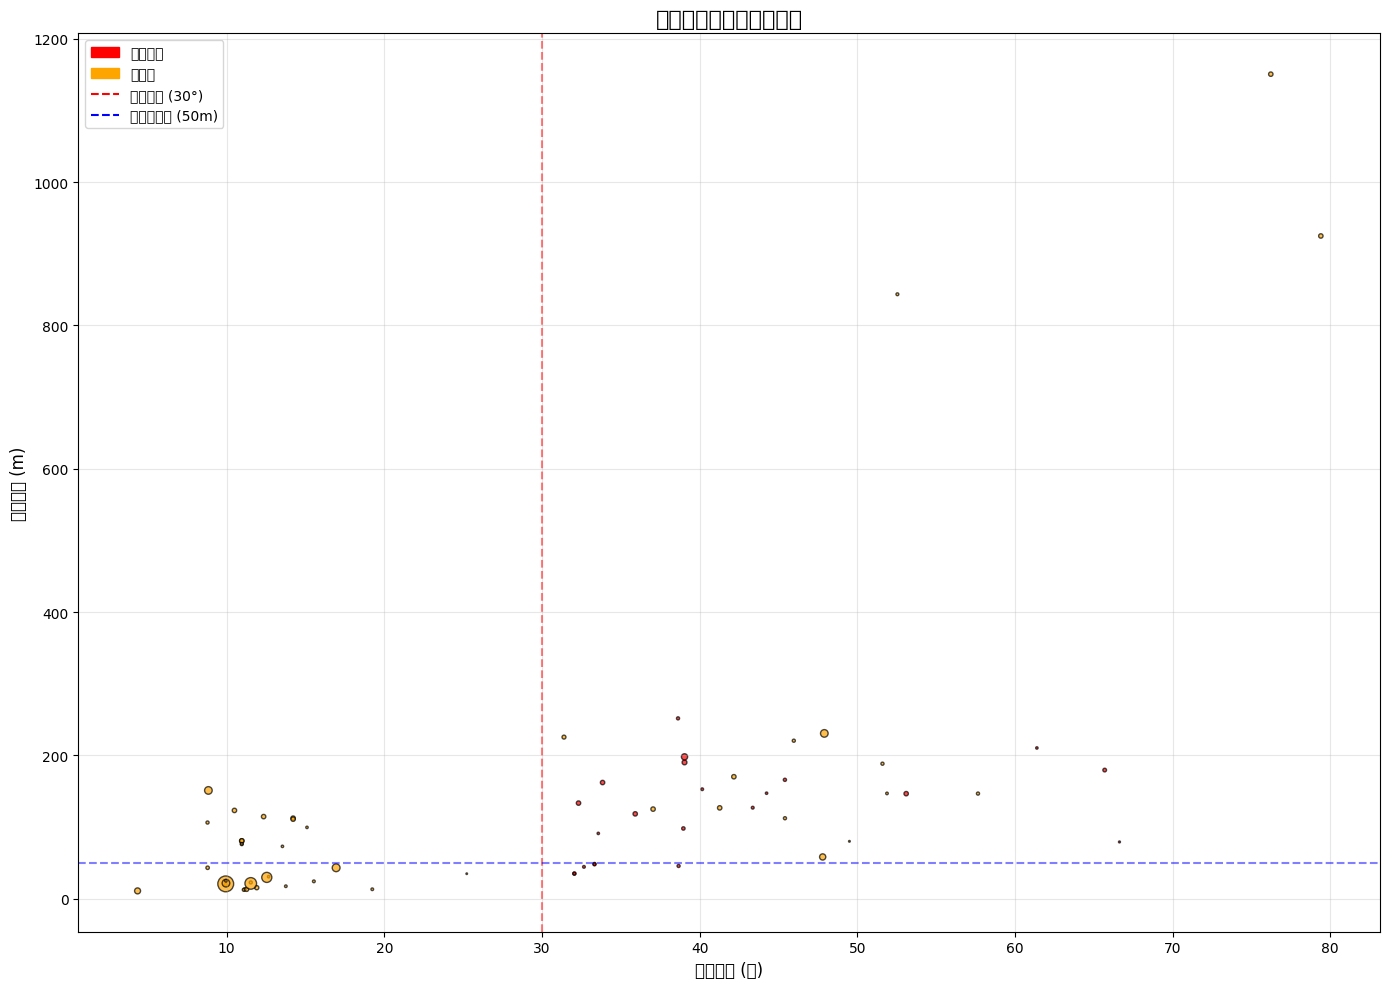

高風險避難所地形分析圖已儲存為 top_risk_terrain_analysis.png

=== Top 10 高風險避難所詳細資料 ===
  shelter_name terrain_risk_level  max_slope  mean_elevation  capacity
         西林天主堂               high  79.401108      924.822731       100
      西林社區活動中心               high  76.226860     1150.632225       100
      奇美社區活動中心            extreme  66.628502       79.109605        20
         銅門收容所            extreme  65.691605      179.414926        70
    磯崎村辦公處活動中心            extreme  63.652252       83.961827         0
        森榮里辦公處            extreme  61.390305      210.267077        30
東興部落原住民多功能活動中心               high  57.985359       55.472047         0
       萬榮鄉立幼兒園               high  57.654732      146.604815        50
        豐濱國中禮堂            extreme  57.256416       36.283164         0
     八里灣基督長老教會            extreme  54.413998      108.427556         0


In [14]:
# 4.2 高風險避難所地形分析圖
print("建立高風險避難所地形分析圖...")

# 篩選高風險避難所
high_risk_shelters = shelters[shelters['terrain_risk_level'].isin(['extreme', 'high'])].copy()

if len(high_risk_shelters) > 0:
    # 創建地形分析圖
    plt.figure(figsize=(14, 10))

    # 散點圖：坡度 vs 高程
    scatter = plt.scatter(high_risk_shelters['max_slope'],
                         high_risk_shelters['mean_elevation'],
                         c=high_risk_shelters['terrain_risk_level'].map({
                             'extreme': 'red',
                             'high': 'orange'
                         }),
                         s=high_risk_shelters['capacity']/10,  # 根據收容量調整點的大小
                         alpha=0.7,
                         edgecolors='black',
                         linewidth=1)

    # 添加門檻線
    plt.axvline(x=SLOPE_THRESHOLD, color='red', linestyle='--', alpha=0.5,
                label=f'坡度門檻 ({SLOPE_THRESHOLD}°)')
    plt.axhline(y=ELEVATION_THRESHOLD, color='blue', linestyle='--', alpha=0.5,  # 修正變數名稱
                label=f'低高程門檻 ({ELEVATION_THRESHOLD}m)')

    plt.xlabel('最大坡度 (度)', fontsize=12)
    plt.ylabel('平均高程 (m)', fontsize=12)
    plt.title('高風險避難所地形分析圖', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)

    # 添加顏色條例
    import matplotlib.patches as mpatches
    extreme_patch = mpatches.Patch(color='red', label='極高風險')
    high_patch = mpatches.Patch(color='orange', label='高風險')
    plt.legend(handles=[extreme_patch, high_patch,
                      plt.Line2D([0], [0], color='red', linestyle='--', label=f'坡度門檻 ({SLOPE_THRESHOLD}°)'),
                      plt.Line2D([0], [0], color='blue', linestyle='--', label=f'低高程門檻 ({ELEVATION_THRESHOLD}m)')],
               fontsize=10)

    plt.tight_layout()
    plt.savefig('top_risk_terrain_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("高風險避難所地形分析圖已儲存為 top_risk_terrain_analysis.png")

    # 顯示前10個高風險避難所詳細資料
    print("\n=== Top 10 高風險避難所詳細資料 ===")
    top_10 = high_risk_shelters.nlargest(10, 'max_slope')[['shelter_name', 'terrain_risk_level', 'max_slope', 'mean_elevation', 'capacity']]
    print(top_10.to_string(index=False))

else:
    print("沒有找到高風險避難所")

## 4. 收容量缺口分析

### Captain's Log: Capacity Assessment Phase
按行政區彙總避難所風險分佈與收容量，識別安全區收容量不足的高風險行政區。產生 Top 10 高風險行政區排名。

In [15]:
# 4.1 按行政區統計
print("進行行政區統計分析...")

# 將避難所與行政區進行空間連接
shelters_with_township = gpd.sjoin(shelters, townships, how='inner', predicate='intersects')
print(f"成功匹配行政區的避難所: {len(shelters_with_township)} 個")

# 確認行政區名稱欄位
township_col = None
for col in townships.columns:
    if 'TOWN' in col.upper() or '區' in col or '鄉' in col or '鎮' in col or '市' in col:
        township_col = col
        break

if township_col is None:
    township_col = townships.columns[0]

print(f"使用行政區欄位: {township_col}")

# 重新命名以方便使用
shelters_with_township = shelters_with_township.rename(columns={township_col: 'township_name'})

# 按行政區和風險等級統計
township_stats = shelters_with_township.groupby(['township_name', 'risk_level']).agg({
    'shelter_name': 'count',
    'capacity': 'sum' if 'capacity' in shelters_with_township.columns else lambda x: 0
}).rename(columns={'shelter_name': 'shelter_count'}).reset_index()

# 建立完整的行政區統計表
township_pivot = township_stats.pivot(
    index='township_name',
    columns='risk_level',
    values=['shelter_count', 'capacity']
).fillna(0)

print(f"\n行政區統計完成: {len(township_pivot)} 個行政區")
print("\n前5個行政區統計:")
print(township_pivot.head())

進行行政區統計分析...
成功匹配行政區的避難所: 198 個
使用行政區欄位: TOWNID

行政區統計完成: 13 個行政區

前5個行政區統計:
              shelter_count                   capacity                      
risk_level             high   low medium safe     high    low  medium   safe
township_name                                                               
U01                    11.0   2.0   15.0  0.0   2371.0  381.0  3867.0    0.0
U02                     9.0   0.0    5.0  0.0   1050.0    0.0   680.0    0.0
U03                     3.0   2.0    1.0  6.0     75.0   75.0     0.0  255.0
U04                     8.0   4.0    4.0  3.0    529.0  258.0   213.0  181.0
U05                     7.0  10.0    4.0  1.0   2285.0  783.0   378.0   53.0


In [16]:
# 4.2 計算風險指數與排名
print("計算風險指數...")

# 重新整理統計資料
risk_summary = township_stats.groupby('township_name').agg({
    'shelter_count': 'sum',
    'capacity': 'sum'
}).reset_index()

# 分別統計各風險等級
high_risk_by_town = township_stats[township_stats['risk_level'] == 'high'].set_index('township_name')
med_risk_by_town = township_stats[township_stats['risk_level'] == 'medium'].set_index('township_name')
low_risk_by_town = township_stats[township_stats['risk_level'] == 'low'].set_index('township_name')
safe_by_town = township_stats[township_stats['risk_level'] == 'safe'].set_index('township_name')

# 合併到主要統計表
risk_summary = risk_summary.set_index('township_name')
risk_summary['high_risk_shelters'] = high_risk_by_town['shelter_count']
risk_summary['high_risk_capacity'] = high_risk_by_town['capacity']
risk_summary['med_risk_shelters'] = med_risk_by_town['shelter_count']
risk_summary['med_risk_capacity'] = med_risk_by_town['capacity']
risk_summary['low_risk_shelters'] = low_risk_by_town['shelter_count']
risk_summary['low_risk_capacity'] = low_risk_by_town['capacity']
risk_summary['safe_shelters'] = safe_by_town['shelter_count']
risk_summary['safe_capacity'] = safe_by_town['capacity']

# 填充 NaN 為 0
risk_summary = risk_summary.fillna(0)

# 計算風險指數（高風險避難所比例）
risk_summary['risk_ratio'] = risk_summary['high_risk_shelters'] / risk_summary['shelter_count']
risk_summary['risk_ratio'] = risk_summary['risk_ratio'].fillna(0)

# 計算安全容量缺口（假設需要疏散風險區所有人口）
total_risk_capacity = risk_summary['high_risk_capacity'] + risk_summary['med_risk_capacity'] + risk_summary['low_risk_capacity']
risk_summary['capacity_gap'] = total_risk_capacity - risk_summary['safe_capacity']

# 排序找出 Top 10 高風險行政區
top_10_risk = risk_summary.sort_values('risk_ratio', ascending=False).head(10)

print("\n=== Top 10 高風險行政區 ===")
print(top_10_risk[[
    'high_risk_shelters', 'med_risk_shelters', 'low_risk_shelters', 'safe_shelters',
    'risk_ratio', 'capacity_gap'
]].round(3))

計算風險指數...

=== Top 10 高風險行政區 ===
               high_risk_shelters  med_risk_shelters  low_risk_shelters  \
township_name                                                             
U02                           9.0                5.0                0.0   
U09                          11.0                2.0                5.0   
U06                          11.0                6.0                2.0   
U08                           4.0                2.0                0.0   
U04                           8.0                4.0                4.0   
U11                           4.0                2.0                2.0   
U01                          11.0               15.0                2.0   
U05                           7.0                4.0               10.0   
U03                           3.0                1.0                2.0   
U07                           2.0                8.0                7.0   

               safe_shelters  risk_ratio  capacity_gap  
township_

## 5. 地形風險視覺化 (Week 4 新增)

### Captain's Log: Terrain Risk Visualization
建立 DEM 陰影圖與複合風險地圖，展示地形與避難所風險的空間關係。這是 ARIA v2.0 的核心視覺化升級。

建立 DEM 陰影圖...
Hillshade 計算完成
地形風險地圖已儲存為 terrain_risk_map.png


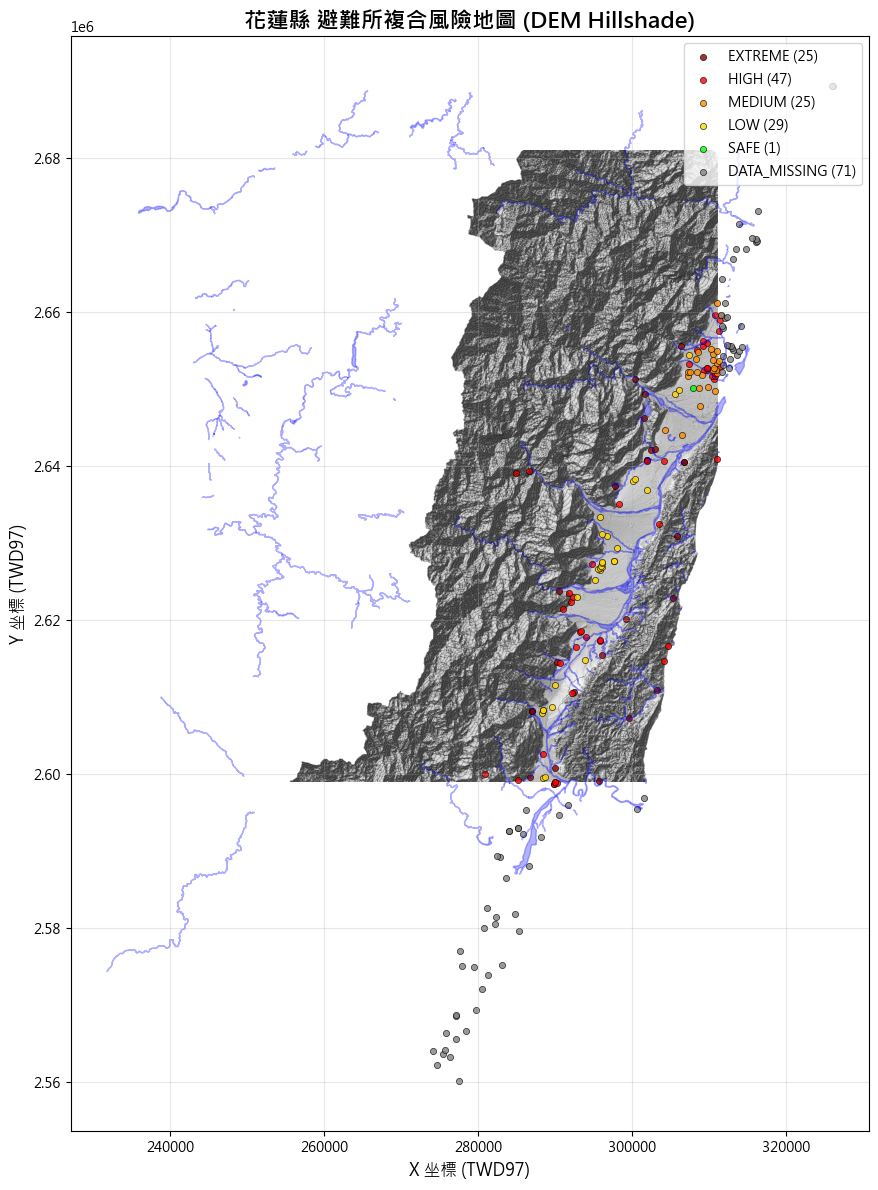

In [17]:
# 5.1 建立 DEM Hillshade
print("建立 DEM 陰影圖...")

try:
    # 計算 hillshade
    from matplotlib.colors import LightSource

    # 取得 DEM 陣列
    dem_array = dem_clipped.values[0]
    dem_array = np.where(np.isfinite(dem_array), dem_array, np.nan)

    # 建立光源
    ls = LightSource(azdeg=315, altdeg=45)

    # 計算 hillshade
    hillshade = ls.hillshade(dem_array, vert_exag=10, dx=20, dy=20)

    print("Hillshade 計算完成")

    # 建立 DEM 與避難所風險疊加圖
    plt.figure(figsize=(15, 12))

    # 設定中文字體
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    # 繪製 hillshade 背景
    extent = [dem_clipped.x.min(), dem_clipped.x.max(),
              dem_clipped.y.min(), dem_clipped.y.max()]

    plt.imshow(hillshade, extent=extent, cmap='gray', alpha=0.7)

    # 疊加 DEM 等高線
    contour_levels = np.linspace(np.nanmin(dem_array), np.nanmax(dem_array), 20)
    plt.contour(dem_clipped.x.values, dem_clipped.y.values, dem_array,
                levels=contour_levels, colors='black', alpha=0.3, linewidths=0.5)

    # 繪製避難所 (依複合風險等級著色)
    risk_colors = {
        'extreme': '#8B0000',    # 深紅色
        'high': '#FF0000',       # 紅色
        'medium': '#FF8C00',     # 橙色
        'low': '#FFD700',        # 金色
        'safe': '#00FF00',       # 綠色
        'data_missing': '#808080' # 灰色
    }

    # 繪製各風險等級的避難所
    for risk_level, color in risk_colors.items():
        risk_shelters = shelters[shelters['terrain_risk_level'] == risk_level]
        if len(risk_shelters) > 0:
            # 轉換座標
            coords = [(geom.x, geom.y) for geom in risk_shelters.geometry]
            x_coords, y_coords = zip(*coords)

            plt.scatter(x_coords, y_coords,
                       c=color, s=20, alpha=0.8,
                       label=f'{risk_level.upper()} ({len(risk_shelters)})',
                       edgecolors='black', linewidths=0.5)

    # 繪製河川
    if 'rivers' in locals():
        rivers_3826 = rivers if rivers.crs == 'EPSG:3826' else rivers.to_crs('EPSG:3826')
        for river in rivers_3826.geometry:
            if river.geom_type == 'Polygon':
                x, y = river.exterior.xy
                plt.fill(x, y, color='blue', alpha=0.3)
            elif river.geom_type == 'LineString':
                x, y = river.xy
                plt.plot(x, y, 'b-', linewidth=1, alpha=0.7)

    plt.title(f'{TARGET_COUNTY} 避難所複合風險地圖 (DEM Hillshade)', fontsize=16, fontweight='bold')
    plt.xlabel('X 坐標 (TWD97)', fontsize=12)
    plt.ylabel('Y 坐標 (TWD97)', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)

    # 儲存圖片
    plt.tight_layout()
    plt.savefig('terrain_risk_map.png', dpi=300, bbox_inches='tight')
    print("地形風險地圖已儲存為 terrain_risk_map.png")

    plt.show()

except Exception as e:
    print(f"DEM 視覺化失敗: {e}")
    print("使用簡化視覺化...")

    # 簡化版：僅顯示避難所風險分佈
    plt.figure(figsize=(12, 8))

    for risk_level, color in risk_colors.items():
        risk_shelters = shelters[shelters['terrain_risk_level'] == risk_level]
        if len(risk_shelters) > 0:
            coords = [(geom.x, geom.y) for geom in risk_shelters.geometry]
            x_coords, y_coords = zip(*coords)

            plt.scatter(x_coords, y_coords,
                       c=color, s=15, alpha=0.7,
                       label=f'{risk_level.upper()} ({len(risk_shelters)})')

    plt.title(f'{TARGET_COUNTY} 避難所複合風險分佈圖', fontsize=14)
    plt.xlabel('X 坐標 (TWD97)')
    plt.ylabel('Y 坐標 (TWD97)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig('terrain_risk_map_simple.png', dpi=300, bbox_inches='tight')
    print("簡化地形風險地圖已儲存為 terrain_risk_map_simple.png")

    plt.show()

建立高風險避難所地形分析圖...
高風險避難所地形分析圖已儲存為 top_risk_terrain_analysis.png


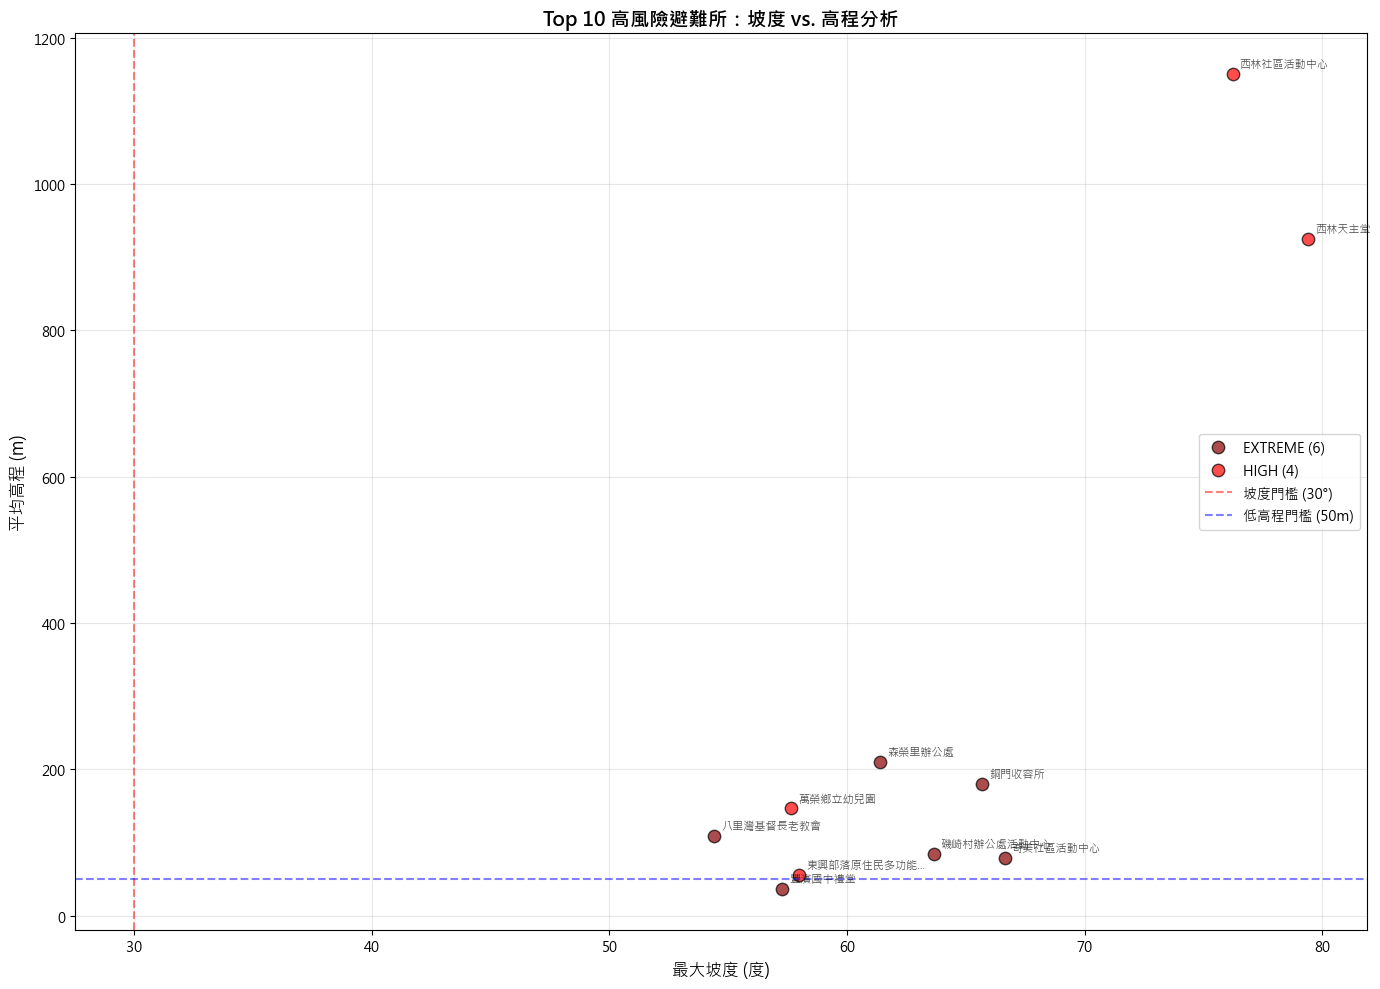


=== Top 10 高風險避難所詳細資料 ===
         避難所名稱    風險等級   最大坡度(°)     平均高程(m)  收容量
         西林天主堂    high 79.401108  924.822731  100
      西林社區活動中心    high 76.226860 1150.632225  100
      奇美社區活動中心 extreme 66.628502   79.109605   20
         銅門收容所 extreme 65.691605  179.414926   70
    磯崎村辦公處活動中心 extreme 63.652252   83.961827    0
        森榮里辦公處 extreme 61.390305  210.267077   30
東興部落原住民多功能活動中心    high 57.985359   55.472047    0
       萬榮鄉立幼兒園    high 57.654732  146.604815   50
        豐濱國中禮堂 extreme 57.256416   36.283164    0
     八里灣基督長老教會 extreme 54.413998  108.427556    0


In [18]:
# 5.2 Top 10 高風險避難所地形分析圖
print("建立高風險避難所地形分析圖...")

# 篩選有效地形資料的避難所
valid_terrain_shelters = shelters[
    (shelters['max_slope'].notna()) &
    (shelters['mean_elevation'].notna()) &
    (shelters['terrain_risk_level'].isin(['extreme', 'high']))
].copy()

if len(valid_terrain_shelters) > 0:
    # 按風險等級排序，取前10名
    top_risk_shelters = valid_terrain_shelters.sort_values('max_slope', ascending=False).head(10)

    plt.figure(figsize=(14, 10))

    # 設定中文字體
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    # 建立散佈圖
    risk_colors_map = {
        'extreme': '#8B0000',
        'high': '#FF0000',
        'medium': '#FF8C00',
        'low': '#FFD700'
    }

    for risk_level in ['extreme', 'high', 'medium', 'low']:
        level_data = top_risk_shelters[top_risk_shelters['terrain_risk_level'] == risk_level]
        if len(level_data) > 0:
            plt.scatter(level_data['max_slope'], level_data['mean_elevation'],
                       c=risk_colors_map[risk_level], s=80, alpha=0.7,
                       label=f'{risk_level.upper()} ({len(level_data)})',
                       edgecolors='black', linewidths=1)

    # 添加避難所標籤
    for idx, shelter in top_risk_shelters.iterrows():
        name = shelter.get('shelter_name', f'避難所{idx}')
        short_name = name[:10] + '...' if len(name) > 10 else name
        plt.annotate(short_name,
                    (shelter['max_slope'], shelter['mean_elevation']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.7)

    # 添加門檻線
    plt.axvline(x=SLOPE_THRESHOLD, color='red', linestyle='--', alpha=0.5,
                label=f'坡度門檻 ({SLOPE_THRESHOLD}°)')
    plt.axhline(y=ELEVATION_THRESHOLD, color='blue', linestyle='--', alpha=0.5,
                label=f'低高程門檻 ({ELEVATION_THRESHOLD}m)')

    plt.xlabel('最大坡度 (度)', fontsize=12)
    plt.ylabel('平均高程 (m)', fontsize=12)
    plt.title('Top 10 高風險避難所：坡度 vs. 高程分析', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # 調整布局
    plt.tight_layout()

    # 儲存圖片
    plt.savefig('top_risk_terrain_analysis.png', dpi=300, bbox_inches='tight')
    print("高風險避難所地形分析圖已儲存為 top_risk_terrain_analysis.png")

    plt.show()

    # 顯示統計表格
    print(f"\n=== Top 10 高風險避難所詳細資料 ===")
    display_cols = ['shelter_name', 'terrain_risk_level', 'max_slope', 'mean_elevation', 'capacity']
    display_df = top_risk_shelters[display_cols].copy()
    display_df.columns = ['避難所名稱', '風險等級', '最大坡度(°)', '平均高程(m)', '收容量']
    print(display_df.to_string(index=False))

else:
    print("沒有足夠的地形資料進行分析")

## 5. 視覺化

### Captain's Log: Visualization Phase
建立互動式風險地圖與靜態統計圖，清晰展示河川緩衝區、避難所風險分佈及高風險行政區排名。

In [19]:
# 5.1 互動式風險地圖
print("建立互動式風險地圖...")

from IPython.display import display

# 轉換 CRS (folium 需要 EPSG:4326)
shelters_4326 = shelters.to_crs('EPSG:4326')
rivers_4326 = rivers.to_crs('EPSG:4326')
buffer_high_4326 = buffer_high.to_crs('EPSG:4326')
buffer_med_4326 = buffer_med.to_crs('EPSG:4326')
buffer_low_4326 = buffer_low.to_crs('EPSG:4326')
townships_4326 = townships.to_crs('EPSG:4326')

# 計算地圖中心（用經緯度）
bounds = shelters_4326.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# 建立地圖
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles='OpenStreetMap'
)

# 低風險 buffer (2km)
folium.GeoJson(
    buffer_low_4326,
    style_function=lambda x: {
        'fillColor': '#FFD700',
        'color': '#FFA500',
        'weight': 1,
        'fillOpacity': 0.2
    },
    name='低風險緩衝區 (2km)'
).add_to(m)

# 中風險 buffer (1km)
folium.GeoJson(
    buffer_med_4326,
    style_function=lambda x: {
        'fillColor': '#FF8C00',
        'color': '#FF6347',
        'weight': 1,
        'fillOpacity': 0.3
    },
    name='中風險緩衝區 (1km)'
).add_to(m)

# 高風險 buffer (500m)
folium.GeoJson(
    buffer_high_4326,
    style_function=lambda x: {
        'fillColor': '#FF0000',
        'color': '#DC143C',
        'weight': 1,
        'fillOpacity': 0.4
    },
    name='高風險緩衝區 (500m)'
).add_to(m)

# 河川
folium.GeoJson(
    rivers_4326,
    style_function=lambda x: {
        'fillColor': '#4169E1',
        'color': '#0000CD',
        'weight': 2
    },
    name='河川'
).add_to(m)

# 鄉鎮市區界
folium.GeoJson(
    townships_4326,
    style_function=lambda x: {
        'fillColor': 'none',
        'color': '#555555',
        'weight': 1
    },
    name='鄉鎮市區界'
).add_to(m)

# 避難所顏色函數
def get_shelter_color(risk_level):
    colors = {
        'high': '#FF0000',
        'medium': '#FF8C00',
        'low': '#FFD700',
        'safe': '#00FF00'
    }
    return colors.get(risk_level, '#808080')

# 添加避難所
for idx, shelter in shelters_4326.iterrows():

    if shelter.geometry.geom_type != "Point":
        continue

    lat = shelter.geometry.y
    lon = shelter.geometry.x

    risk_level = shelter['risk_level']
    name = shelter.get('shelter_name', f'避難所 {idx}')
    capacity = shelter.get('capacity', 0)

    popup = folium.Popup(
        f"<b>{name}</b><br>"
        f"風險等級: {risk_level}<br>"
        f"收容人數: {capacity}",
        max_width=250
    )

    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        popup=popup,
        color=get_shelter_color(risk_level),
        fill=True,
        fillColor=get_shelter_color(risk_level),
        fillOpacity=0.8
    ).add_to(m)

# 圖層控制
folium.LayerControl().add_to(m)

# 儲存地圖
m.save('risk_map.html')

print("互動式風險地圖已儲存為 risk_map.html")

# 在 Jupyter Notebook 顯示
# display(m)

建立互動式風險地圖...
互動式風險地圖已儲存為 risk_map.html


建立 Top 10 高風險行政區統計圖...
統計圖已儲存為 risk_map.png


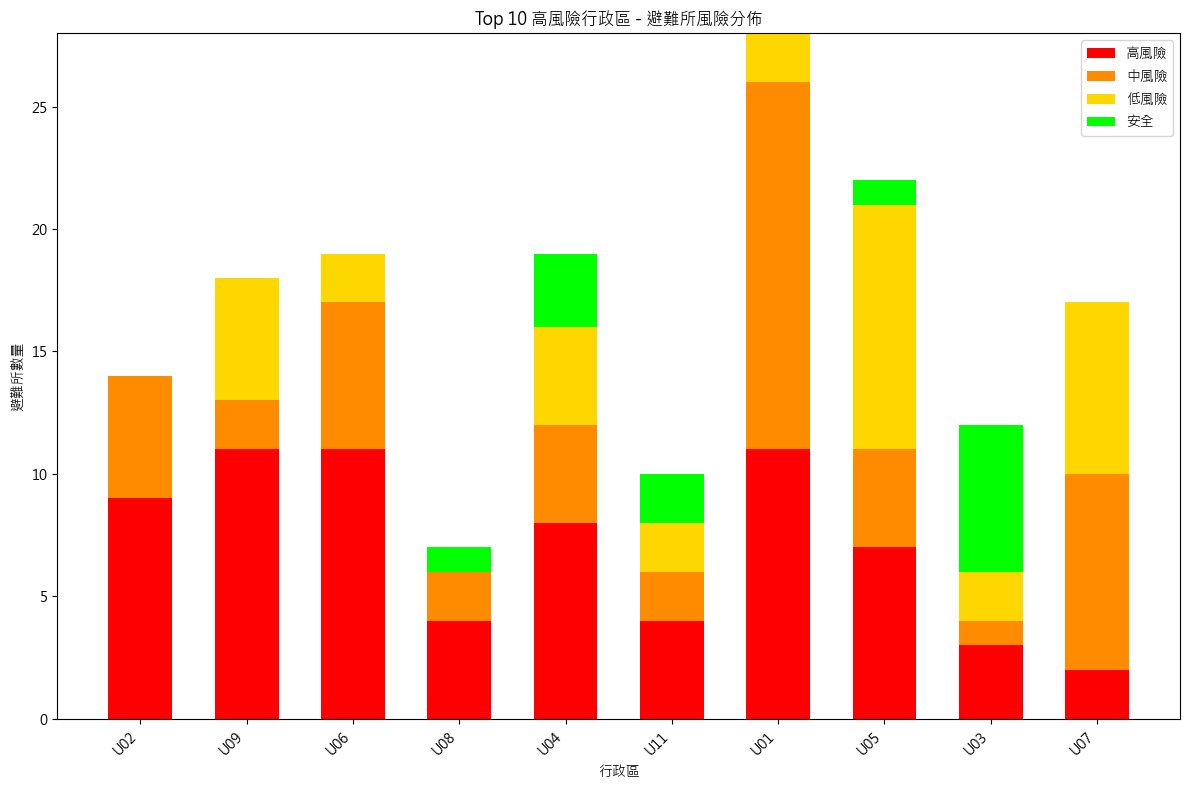

In [20]:
# 5.2 Top 10 高風險行政區長條圖
import matplotlib.pyplot as plt

print("建立 Top 10 高風險行政區統計圖...")
plt.figure(figsize=(12, 8))

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 準備資料
top_10_display = top_10_risk.head(10)
township_names = top_10_display.index.tolist()

# 建立堆疊長條圖
width = 0.6
x = range(len(township_names))

# 繪製各風險等級的避難所數量
p1 = plt.bar(x, top_10_display['high_risk_shelters'], width, label='高風險', color='#FF0000')
p2 = plt.bar(x, top_10_display['med_risk_shelters'], width,
             bottom=top_10_display['high_risk_shelters'], label='中風險', color='#FF8C00')
p3 = plt.bar(x, top_10_display['low_risk_shelters'], width,
             bottom=top_10_display['high_risk_shelters'] + top_10_display['med_risk_shelters'],
             label='低風險', color='#FFD700')
p4 = plt.bar(x, top_10_display['safe_shelters'], width,
             bottom=top_10_display['high_risk_shelters'] + top_10_display['med_risk_shelters'] + top_10_display['low_risk_shelters'],
             label='安全', color='#00FF00')

plt.xlabel('行政區')
plt.ylabel('避難所數量')
plt.title('Top 10 高風險行政區 - 避難所風險分佈')
plt.xticks(x, township_names, rotation=45, ha='right')
plt.legend()
plt.tight_layout()

# 儲存圖片
plt.savefig('risk_map.png', dpi=300, bbox_inches='tight')
print("統計圖已儲存為 risk_map.png")

plt.show()

## 6. 結果匯出

### Captain's Log: Mission Debrief
匯出分析結果，包括避難所風險清單 JSON 檔案，確保所有決策相關資訊完整記錄。

In [21]:
# 6.1 匯出地形風險清單 (Week 4 升級版)
print("匯出地形風險清單...")

# 準備匯出資料
terrain_risk_audit = []

# 檢查並確保所有必要變數存在
required_vars = ['shelters', 'townships', 'township_col']
missing_vars = [var for var in required_vars if var not in locals()]

if missing_vars:
    print(f"錯誤: 缺少必要變數: {missing_vars}")
    print("請確保已執行所有前面的分析單元")
else:
    print(f"開始匯出 {len(shelters)} 個避難所的地形風險資料...")

    for idx, shelter in shelters.iterrows():
        try:
            # 轉換幾何座標回 WGS84
            shelter_4326 = gpd.GeoSeries([shelter.geometry], crs='EPSG:3826').to_crs('EPSG:4326')[0]

            audit_record = {
                'shelter_id': str(idx),
                'name': shelter.get('shelter_name', f'避難所_{idx}'),
                'river_risk_level': shelter['risk_level'],  # 原有河川風險
                'terrain_risk_level': shelter['terrain_risk_level'],  # 新增地形風險
                'river_distance_category': shelter['river_distance_category'],
                'capacity': int(shelter.get('capacity', 0)),
                'longitude': float(shelter_4326.x),
                'latitude': float(shelter_4326.y),
                'address': shelter.get('避難收容處所地址', ''),
                'township': '',
                # Week 4 新增地形指標
                'mean_elevation': float(shelter['mean_elevation']) if pd.notna(shelter['mean_elevation']) else None,
                'max_elevation': float(shelter['max_elevation']) if pd.notna(shelter['max_elevation']) else None,
                'std_elevation': float(shelter['std_elevation']) if pd.notna(shelter['std_elevation']) else None,
                'mean_slope': float(shelter['mean_slope']) if pd.notna(shelter['mean_slope']) else None,
                'max_slope': float(shelter['max_slope']) if pd.notna(shelter['max_slope']) else None,
                'std_slope': float(shelter['std_slope']) if pd.notna(shelter['std_slope']) else None
            }

            # 嘗試獲取行政區資訊
            try:
                matching_township = townships[townships.contains(shelter.geometry)]
                if not matching_township.empty:
                    audit_record['township'] = matching_township.iloc[0].get(township_col, '')
            except Exception as e:
                # 行政區匹配失敗不影響主要匯出
                pass

            terrain_risk_audit.append(audit_record)

        except Exception as e:
            print(f"處理避難所 {idx} 時出錯: {e}")
            continue

    # 儲存為 JSON
    try:
        with open('terrain_risk_audit.json', 'w', encoding='utf-8') as f:
            json.dump(terrain_risk_audit, f, ensure_ascii=False, indent=2)
        print(f"地形風險清單已匯出: {len(terrain_risk_audit)} 筆記錄")
    except Exception as e:
        print(f"儲存 JSON 檔案時出錯: {e}")

    # 顯示統計摘要
    print("\n=== ARIA v2.0 任務完成摘要 ===")
    print(f"總避難所數量: {len(shelters):,}")

    # 河川風險統計
    print(f"\n--- 河川距離風險 ---")
    river_risk_counts = shelters['risk_level'].value_counts()
    for level, count in river_risk_counts.items():
        print(f"{level}: {count:,} 個避難所")

    # 地形風險統計
    print(f"\n--- 複合地形風險 ---")
    terrain_risk_counts = shelters['terrain_risk_level'].value_counts()
    for level, count in terrain_risk_counts.items():
        print(f"{level}: {count:,} 個避難所")

    # 地形統計摘要
    valid_terrain = shelters[shelters['mean_elevation'].notna()]
    if len(valid_terrain) > 0:
        print(f"\n--- 地形統計摘要 ---")
        print(f"有效地形資料: {len(valid_terrain):,} 個避難所")
        print(f"平均高程範圍: {valid_terrain['mean_elevation'].min():.1f} - {valid_terrain['mean_elevation'].max():.1f}m")
        print(f"最大坡度範圍: {valid_terrain['max_slope'].min():.2f} - {valid_terrain['max_slope'].max():.2f}°")

        # 風險因子統計
        steep_count = (valid_terrain['max_slope'] > SLOPE_THRESHOLD).sum()
        low_elev_count = (valid_terrain['mean_elevation'] < ELEVATION_THRESHOLD).sum()
        print(f"超過坡度門檻: {steep_count:,} 個")
        print(f"低高程區域: {low_elev_count:,} 個")

    # 收容量分析
    if 'capacity' in shelters.columns:
        total_capacity = shelters['capacity'].sum()

        print(f"\n--- 收容量分析 ---")
        print(f"總收容量: {total_capacity:,.0f} 人")

        # 按複合風險等級統計收容量
        capacity_by_terrain_risk = shelters.groupby('terrain_risk_level')['capacity'].sum()
        for level, capacity in capacity_by_terrain_risk.items():
            print(f"{level}風險收容量: {capacity:,.0f} 人")

        # 安全容量缺口
        safe_capacity = capacity_by_terrain_risk.get('safe', 0)
        risk_capacity = total_capacity - safe_capacity
        capacity_gap = risk_capacity - safe_capacity
        print(f"安全容量缺口: {capacity_gap:,.0f} 人")

    print(f"\n=== 輸出檔案 ===")
    print("✓ risk_map.html - 互動式風險地圖")
    print("✓ risk_map.png - Top 10 高風險行政區統計圖")
    print("✓ terrain_risk_map.png - DEM 地形風險地圖")
    print("✓ top_risk_terrain_analysis.png - 高風險避難所地形分析")
    print("✓ terrain_risk_audit.json - 地形風險清單 (Week 4 新增)")

    print(f"\n🎯 ARIA v2.0 地形整合版任務完成！")
    print(f"📍 分析範圍: {TARGET_COUNTY}")
    print(f"⛰️ 地形門檻: 坡度 {SLOPE_THRESHOLD}°, 高程 {ELEVATION_THRESHOLD}m")

匯出地形風險清單...
開始匯出 198 個避難所的地形風險資料...
地形風險清單已匯出: 198 筆記錄

=== ARIA v2.0 任務完成摘要 ===
總避難所數量: 198

--- 河川距離風險 ---
high: 70 個避難所
medium: 53 個避難所
low: 42 個避難所
safe: 33 個避難所

--- 複合地形風險 ---
data_missing: 71 個避難所
high: 47 個避難所
low: 29 個避難所
extreme: 25 個避難所
medium: 25 個避難所
safe: 1 個避難所

--- 地形統計摘要 ---
有效地形資料: 127 個避難所
平均高程範圍: 10.8 - 1150.6m
最大坡度範圍: 3.79 - 79.40°
超過坡度門檻: 41 個
低高程區域: 52 個

--- 收容量分析 ---
總收容量: 20,561 人
data_missing風險收容量: 5,860 人
extreme風險收容量: 1,425 人
high風險收容量: 6,398 人
low風險收容量: 2,652 人
medium風險收容量: 4,173 人
safe風險收容量: 53 人
安全容量缺口: 20,455 人

=== 輸出檔案 ===
✓ risk_map.html - 互動式風險地圖
✓ risk_map.png - Top 10 高風險行政區統計圖
✓ terrain_risk_map.png - DEM 地形風險地圖
✓ top_risk_terrain_analysis.png - 高風險避難所地形分析
✓ terrain_risk_audit.json - 地形風險清單 (Week 4 新增)

🎯 ARIA v2.0 地形整合版任務完成！
📍 分析範圍: 花蓮縣
⛰️ 地形門檻: 坡度 30°, 高程 50m
